# Lab 03: Computer Vision Prototyping & Object Detection Pipeline

In [4]:
import os
import time
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

os.makedirs('outputs', exist_ok=True)

## Task 1: Preprocessing Pipeline for Traffic Camera

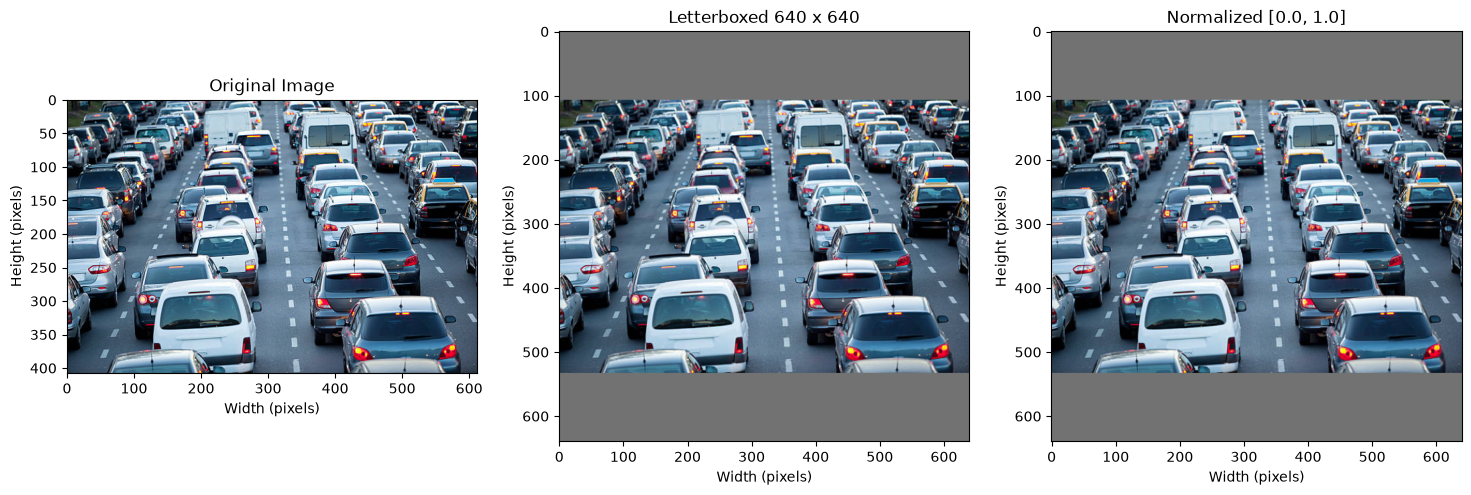

Original  : shape (408, 612, 3) dtype uint8 min 0 max 255
Letterbox : shape (640, 640, 3) dtype uint8 min 0 max 255
Normalized: shape (640, 640, 3) dtype float32 min 0.0 max 1.0


In [5]:
img = cv2.imread('images/traffic.jpg')

h, w = img.shape[:2]
scale = 640 / max(h, w)
new_w, new_h = int(w * scale), int(h * scale)
resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

letterbox = np.full((640, 640, 3), 114, dtype=np.uint8)
top = (640 - new_h) // 2
left = (640 - new_w) // 2
letterbox[top:top + new_h, left:left + new_w] = resized

normalized = letterbox.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')

axes[1].imshow(cv2.cvtColor(letterbox, cv2.COLOR_BGR2RGB))
axes[1].set_title('Letterboxed 640 x 640')

axes[2].imshow(cv2.cvtColor(normalized, cv2.COLOR_BGR2RGB))
axes[2].set_title('Normalized [0.0, 1.0]')

for ax in axes:
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Height (pixels)')

plt.show()

print('Original  : shape', img.shape, 'dtype', img.dtype, 'min', img.min(), 'max', img.max())
print('Letterbox : shape', letterbox.shape, 'dtype', letterbox.dtype, 'min', letterbox.min(), 'max', letterbox.max())
print('Normalized: shape', normalized.shape, 'dtype', normalized.dtype, 'min', normalized.min(), 'max', normalized.max())

## Task 2: Industrial Defect Detection (Color Space and Thresholding)

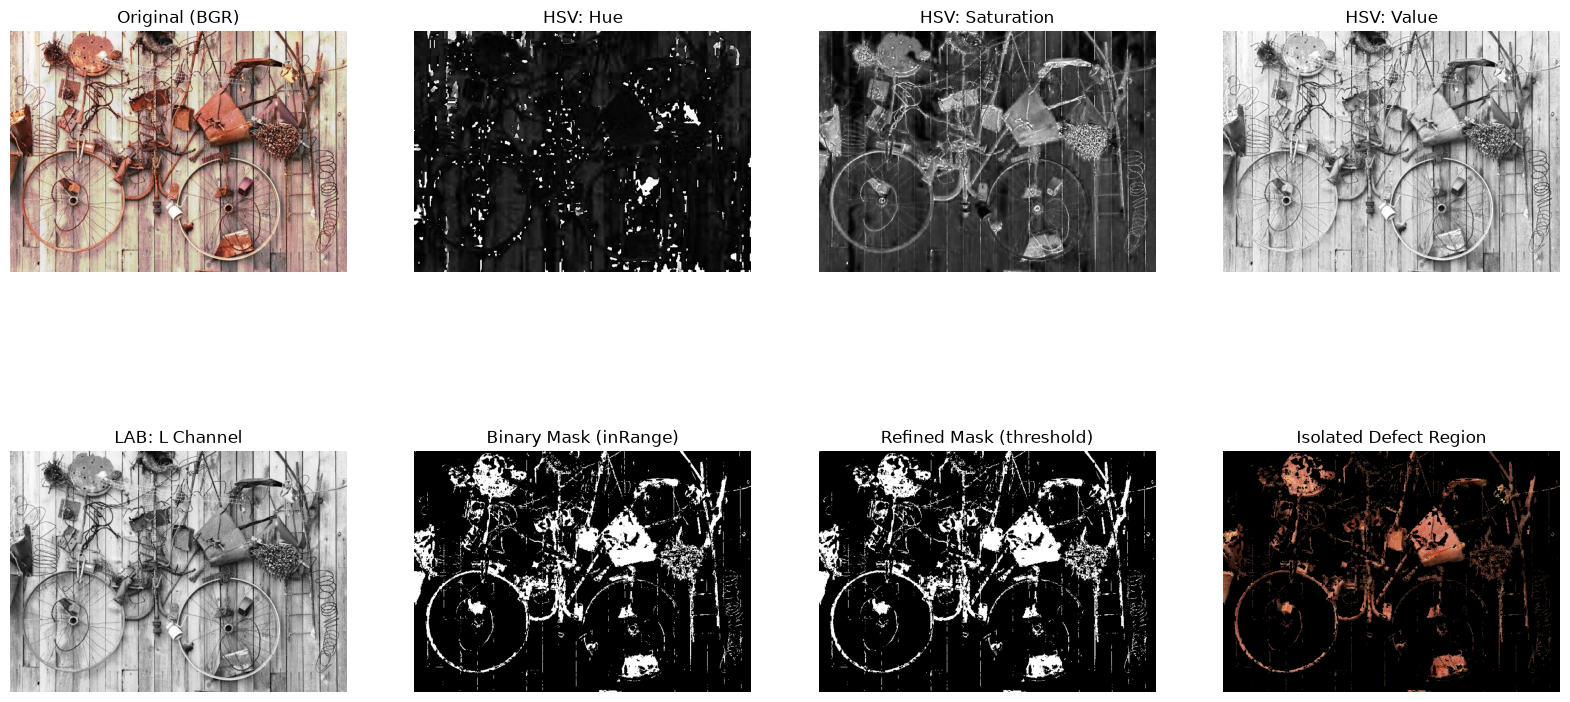

In [6]:
img = cv2.imread('images/product.jpg')

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

lower = np.array([5, 100, 50])
upper = np.array([25, 255, 255])

mask = cv2.inRange(hsv, lower, upper)
_, refined = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
result = cv2.bitwise_and(img, img, mask=refined)

panels = [
    (cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 'Original (BGR)', None),
    (hsv[:, :, 0], 'HSV: Hue', 'gray'),
    (hsv[:, :, 1], 'HSV: Saturation', 'gray'),
    (hsv[:, :, 2], 'HSV: Value', 'gray'),
    (lab[:, :, 0], 'LAB: L Channel', 'gray'),
    (mask, 'Binary Mask (inRange)', 'gray'),
    (refined, 'Refined Mask (threshold)', 'gray'),
    (cv2.cvtColor(result, cv2.COLOR_BGR2RGB), 'Isolated Defect Region', None),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, (image, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

plt.show()

## Task 3: Edge Detection and Noise Reduction (Medical Imaging)

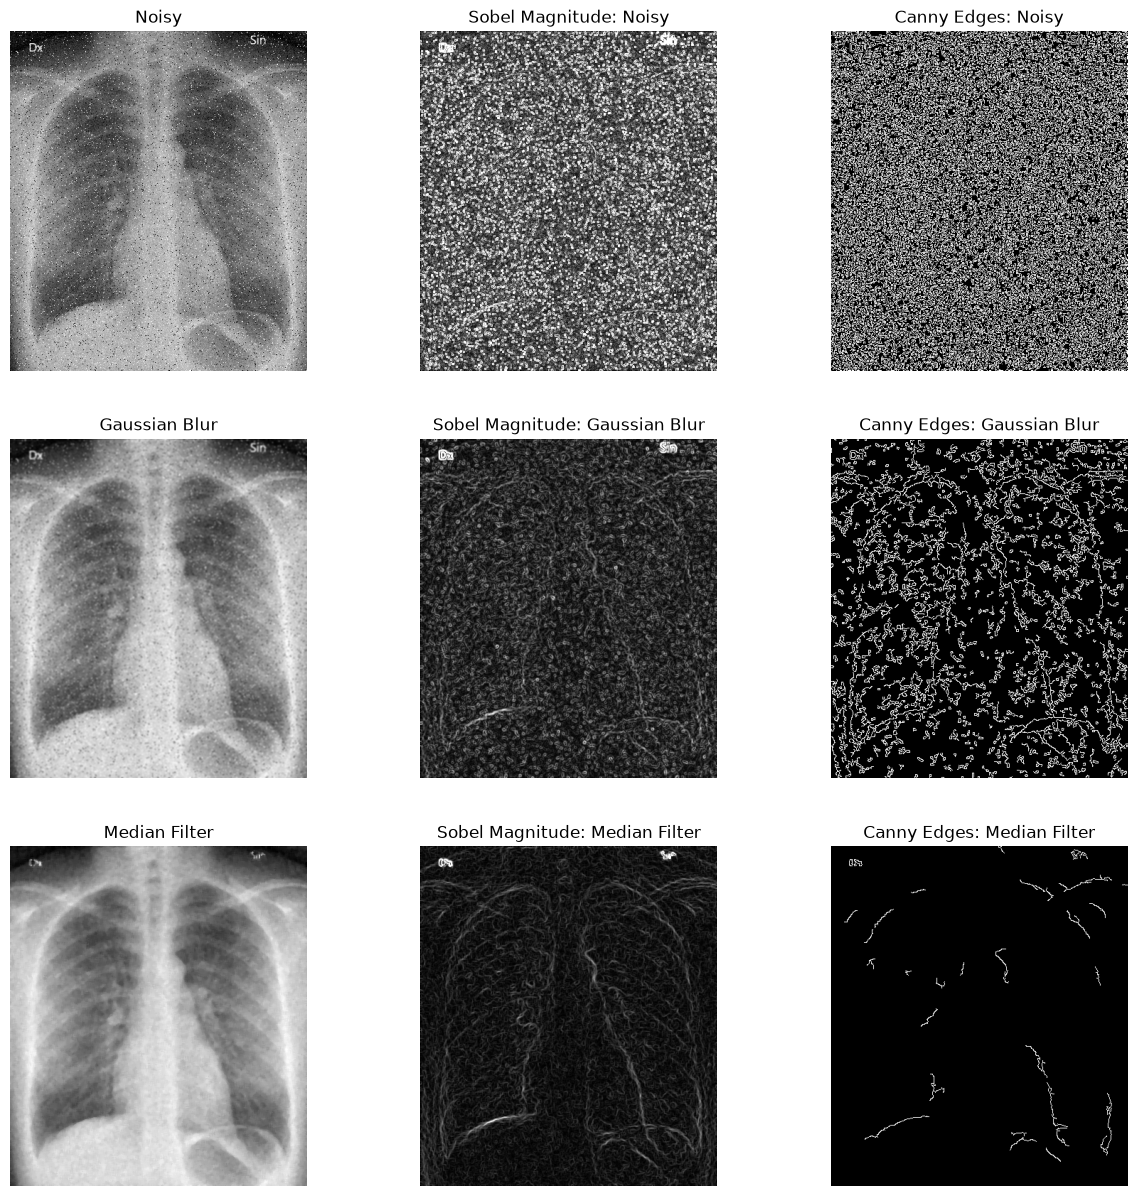

,Version,PSNR (dB),Canny Edge Pixels,Edge IoU vs Clean
0,Noisy,18.38,75921,0.028
1,Gaussian Blur,28.72,27296,0.057
2,Median Filter,31.71,1690,0.095


In [7]:
clean = cv2.imread('images/scan.jpg', cv2.IMREAD_GRAYSCALE)

rng = np.random.default_rng(0)
noisy = clean.astype(np.float32) + rng.normal(0, 15, clean.shape)
rand = rng.random(clean.shape)
noisy[rand < 0.02] = 0
noisy[rand > 0.98] = 255
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)
median = cv2.medianBlur(noisy, 5)

reference_edges = cv2.Canny(clean, 50, 150)

versions = {'Noisy': noisy, 'Gaussian Blur': gaussian, 'Median Filter': median}
rows = []

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, (name, image) in enumerate(versions.items()):
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.convertScaleAbs(cv2.magnitude(sobel_x, sobel_y))

    canny = cv2.Canny(image, 50, 150)

    overlap = np.logical_and(canny > 0, reference_edges > 0).sum()
    union = np.logical_or(canny > 0, reference_edges > 0).sum()

    rows.append({
        'Version': name,
        'PSNR (dB)': round(cv2.PSNR(clean, image), 2),
        'Canny Edge Pixels': int((canny > 0).sum()),
        'Edge IoU vs Clean': round(overlap / union, 3),
    })

    axes[i, 0].imshow(image, cmap='gray')
    axes[i, 0].set_title(name)
    axes[i, 1].imshow(magnitude, cmap='gray')
    axes[i, 1].set_title('Sobel Magnitude: ' + name)
    axes[i, 2].imshow(canny, cmap='gray')
    axes[i, 2].set_title('Canny Edges: ' + name)

for ax in axes.ravel():
    ax.axis('off')

plt.show()

pd.DataFrame(rows)

## Task 4: YOLO Benchmarking (Nano vs Medium)

yolov8n.pt person 0.84 (535, 270, 608, 391)
yolov8n.pt person 0.83 (267, 270, 322, 386)
yolov8n.pt person 0.82 (101, 262, 152, 389)
yolov8n.pt person 0.82 (451, 269, 508, 379)
yolov8n.pt person 0.81 (180, 262, 237, 396)
yolov8n.pt truck 0.78 (75, 217, 194, 326)
yolov8n.pt person 0.73 (344, 274, 387, 375)
yolov8n.pt car 0.7 (372, 281, 412, 341)
yolov8n.pt car 0.6 (407, 255, 514, 357)
yolov8n.pt truck 0.6 (252, 196, 355, 350)
yolov8n.pt person 0.6 (0, 280, 28, 379)
yolov8n.pt car 0.58 (575, 284, 634, 350)
yolov8n.pt car 0.53 (511, 283, 548, 344)
yolov8n.pt person 0.45 (601, 265, 622, 299)
yolov8n.pt car 0.38 (529, 278, 636, 354)
yolov8n.pt person 0.33 (54, 274, 70, 330)
yolov8n.pt person 0.32 (59, 277, 73, 321)
yolov8n.pt person 0.3 (632, 261, 645, 316)
yolov8n.pt truck 0.29 (255, 239, 353, 348)
yolov8m.pt person 0.89 (448, 267, 504, 379)
yolov8m.pt person 0.89 (181, 264, 236, 396)
yolov8m.pt person 0.88 (533, 272, 607, 389)
yolov8m.pt person 0.87 (267, 270, 321, 385)
yolov8m.pt person 0

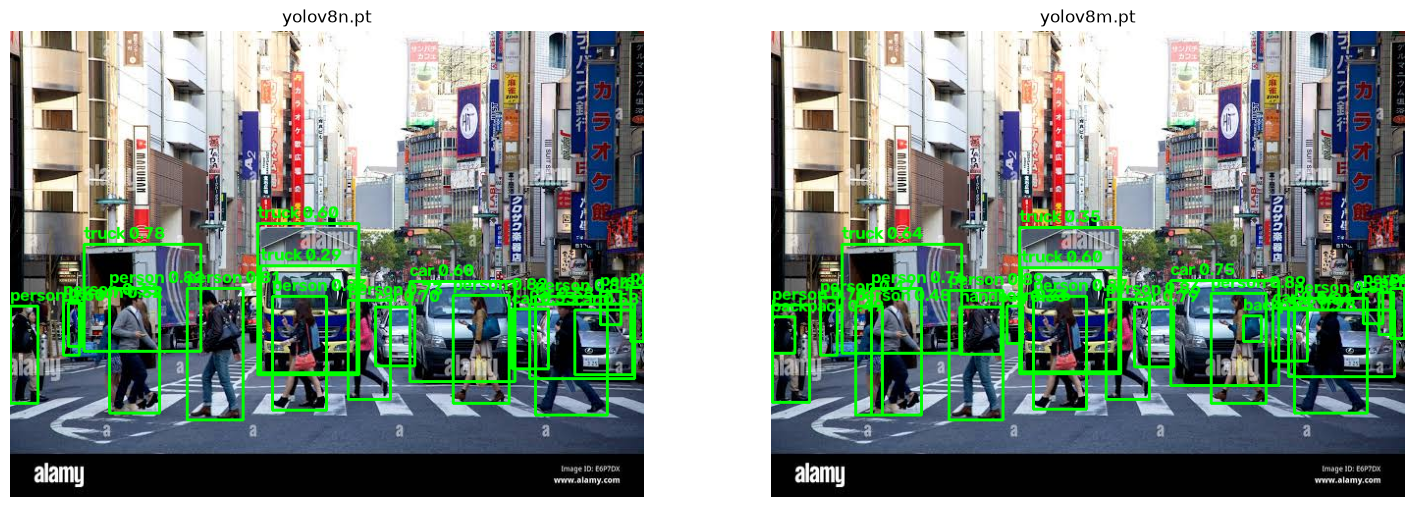

,Model,Latency (ms),Total Detections,Class Counts,Avg Confidence
0,yolov8n.pt,330.7,19,"{'person': 11, 'truck': 3, 'car': 5}",0.596
1,yolov8m.pt,731.2,23,"{'person': 12, 'car': 5, 'truck': 3, 'backpack...",0.605


In [8]:
img = cv2.imread('images/street.jpg')

model_names = ['yolov8n.pt', 'yolov8m.pt']
rows = []

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for i, model_name in enumerate(model_names):
    model = YOLO(model_name)
    model(img, verbose=False)

    start = time.time()
    result = model(img, verbose=False)[0]
    latency = (time.time() - start) * 1000

    output = img.copy()
    confidences = []
    labels = []

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        confidence = float(box.conf[0])
        label = model.names[int(box.cls[0])]

        confidences.append(confidence)
        labels.append(label)
        print(model_name, label, round(confidence, 2), (x1, y1, x2, y2))

        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(output, f'{label} {confidence:.2f}', (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    axes[i].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    axes[i].set_title(model_name)
    axes[i].axis('off')

    rows.append({
        'Model': model_name,
        'Latency (ms)': round(latency, 1),
        'Total Detections': len(labels),
        'Class Counts': dict(Counter(labels)),
        'Avg Confidence': round(float(np.mean(confidences)), 3) if confidences else 0,
    })

plt.show()

pd.DataFrame(rows)

## Task 5: Retail Inventory Monitoring

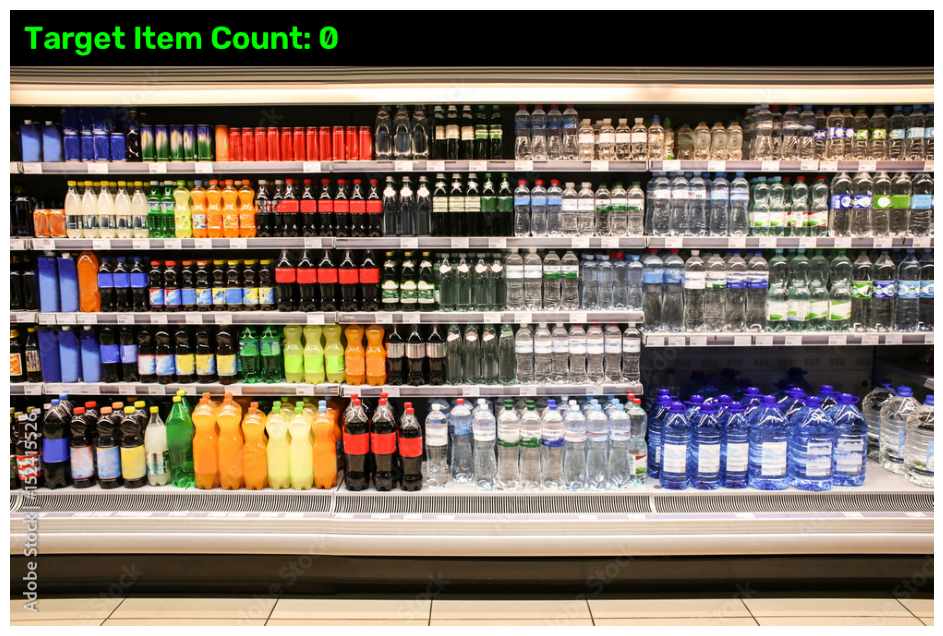

In [9]:
model = YOLO('yolov8m.pt')
img = cv2.imread('images/shelf.jpg')

target_ids = [39]

result = model(img, verbose=False)[0]
output = img.copy()
count = 0

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    if class_id in target_ids and confidence > 0.50:
        count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(output, f'{confidence:.2f}', (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

cv2.rectangle(output, (0, 0), (output.shape[1], 60), (0, 0, 0), -1)
cv2.putText(output, f'Target Item Count: {count}', (15, 42),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

cv2.imwrite('outputs/task5_result.jpg', output)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Task 6: Intrusion Alerting with ROI

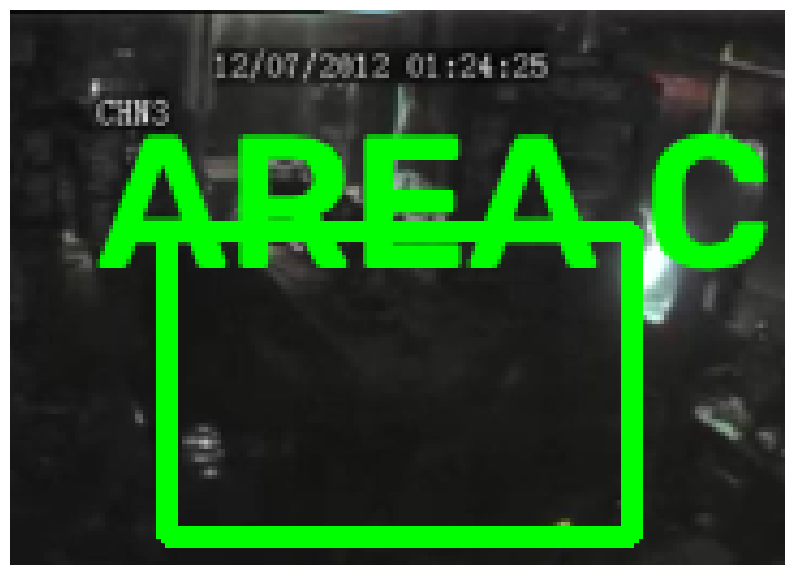

In [11]:
model = YOLO('yolov8n.pt')
img = cv2.imread('images/people.jpg')
h, w = img.shape[:2]

roi = np.array([
    [int(w * 0.2), int(h * 0.4)],
    [int(w * 0.8), int(h * 0.4)],
    [int(w * 0.8), int(h * 0.95)],
    [int(w * 0.2), int(h * 0.95)],
], dtype=np.int32)

result = model(img, verbose=False)[0]
output = img.copy()
intrusion = False

for box in result.boxes:
    if int(box.cls[0]) != 0:
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    xc = (x1 + x2) // 2
    yc = (y1 + y2) // 2

    inside = cv2.pointPolygonTest(roi, (float(xc), float(yc)), False) >= 0
    if inside:
        intrusion = True

    cv2.rectangle(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.circle(output, (xc, yc), 5, (0, 255, 255), -1)

color = (0, 0, 255) if intrusion else (0, 255, 0)
cv2.polylines(output, [roi], True, color, 3)

if intrusion:
    cv2.putText(output, 'INTRUSION DETECTED', (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)
else:
    cv2.putText(output, 'AREA CLEAR', (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 4)

cv2.imwrite('outputs/task6_result.jpg', output)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Task 7: Real-Time Webcam Detection Dashboard

In [12]:
%%writefile live_detection.py
import os
import time

import cv2
from ultralytics import YOLO


def load_model(path='yolov8n.pt'):
    return YOLO(path)


def draw_fps(frame, fps):
    cv2.putText(frame, f'FPS: {fps:.1f}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)


def save_frame(frame):
    os.makedirs('captures', exist_ok=True)
    filename = time.strftime('captures/%Y%m%d_%H%M%S.jpg')
    cv2.imwrite(filename, frame)
    print('Saved', filename)


def main():
    model = load_model()
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print('Cannot open webcam')
        return

    prev_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)
        annotated = results[0].plot()

        now = time.time()
        fps = 1 / (now - prev_time)
        prev_time = now
        draw_fps(annotated, fps)

        cv2.imshow('Live Detection', annotated)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        if key == ord('s'):
            save_frame(annotated)

    cap.release()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    main()

Overwriting live_detection.py


In [13]:
import sys

!"{sys.executable}" live_detection.py

Traceback (most recent call last):
  File "c:\Users\Abdul Rehman Ali\OneDrive\Documents\vs code\AIPDD\Lab03\AI_Project\live_detection.py", line 59, in <module>
    main()
  File "c:\Users\Abdul Rehman Ali\OneDrive\Documents\vs code\AIPDD\Lab03\AI_Project\live_detection.py", line 38, in main
    results = model(frame, verbose=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Abdul Rehman Ali\OneDrive\Documents\vs code\AIPDD\aipdd_env\Lib\site-packages\ultralytics\engine\model.py", line 168, in __call__
    return self.predict(source, stream, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Abdul Rehman Ali\OneDrive\Documents\vs code\AIPDD\aipdd_env\Lib\site-packages\ultralytics\engine\model.py", line 564, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
                                                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil

## Task 8: Webcam Surveillance with Event Logging

In [14]:
%%writefile surveillance_logger.py
import os
import time

import cv2
from ultralytics import YOLO

TARGET_CLASSES = ['person', 'cell phone']
THRESHOLD = 0.65
COOLDOWN = 2


def setup():
    os.makedirs('alerts', exist_ok=True)
    if not os.path.exists('events.log'):
        with open('events.log', 'w') as f:
            f.write('Timestamp,Class,Confidence,X1,Y1,X2,Y2\n')


def get_events(result, names):
    events = []
    for box in result.boxes:
        label = names[int(box.cls[0])]
        confidence = float(box.conf[0])
        if label in TARGET_CLASSES and confidence > THRESHOLD:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            events.append((label, confidence, x1, y1, x2, y2))
    return events


def log_events(frame, events):
    file_stamp = time.strftime('%Y%m%d_%H%M%S')
    log_stamp = time.strftime('%Y-%m-%d %H:%M:%S')
    cv2.imwrite(f'alerts/{file_stamp}.jpg', frame)
    with open('events.log', 'a') as f:
        for label, confidence, x1, y1, x2, y2 in events:
            f.write(f'{log_stamp},{label},{confidence:.2f},{x1},{y1},{x2},{y2}\n')
    print('Logged', len(events), 'event(s) at', log_stamp)


def draw_indicator(frame):
    height, width = frame.shape[:2]
    cv2.rectangle(frame, (0, 0), (width - 1, height - 1), (0, 0, 255), 8)
    cv2.putText(frame, 'LOGGING EVENT', (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)


def main():
    setup()
    model = YOLO('yolov8n.pt')
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print('Cannot open webcam')
        return

    last_log = 0
    indicator_until = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        result = model(frame, verbose=False)[0]
        annotated = result.plot()
        events = get_events(result, model.names)
        now = time.time()

        if events and now - last_log >= COOLDOWN:
            log_events(annotated, events)
            last_log = now
            indicator_until = now + 1

        if now < indicator_until:
            draw_indicator(annotated)

        cv2.imshow('Surveillance', annotated)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    main()

Overwriting surveillance_logger.py


In [15]:
import sys

!"{sys.executable}" surveillance_logger.py

Logged 1 event(s) at 2026-10-04 23:51:46
Logged 1 event(s) at 2026-10-04 23:51:48
Logged 1 event(s) at 2026-10-04 23:51:50
Logged 1 event(s) at 2026-10-04 23:51:52
Logged 1 event(s) at 2026-10-04 23:51:54
Logged 1 event(s) at 2026-10-04 23:51:56
Logged 1 event(s) at 2026-10-04 23:51:58
Logged 1 event(s) at 2026-10-04 23:52:00
Logged 1 event(s) at 2026-10-04 23:52:02
Logged 1 event(s) at 2026-10-04 23:52:04
Logged 1 event(s) at 2026-10-04 23:52:06
Logged 1 event(s) at 2026-10-04 23:52:08
Logged 1 event(s) at 2026-10-04 23:52:10
Logged 1 event(s) at 2026-10-04 23:52:12
Logged 1 event(s) at 2026-10-04 23:52:15
Logged 1 event(s) at 2026-10-04 23:52:17
Logged 1 event(s) at 2026-10-04 23:52:19
Logged 1 event(s) at 2026-10-04 23:52:21
Logged 1 event(s) at 2026-10-04 23:52:23
Logged 1 event(s) at 2026-10-04 23:52:25
Logged 1 event(s) at 2026-10-04 23:52:27


In [16]:
print(open('events.log').read())
print(os.listdir('alerts'))

Timestamp,Class,Confidence,X1,Y1,X2,Y2
2026-10-04 23:51:46,person,0.85,100,140,635,479
2026-10-04 23:51:48,person,0.83,113,146,612,479
2026-10-04 23:51:50,person,0.91,31,0,639,479
2026-10-04 23:51:52,person,0.88,63,64,638,479
2026-10-04 23:51:54,person,0.88,49,62,638,479
2026-10-04 23:51:56,person,0.92,58,61,638,479
2026-10-04 23:51:58,person,0.89,64,64,639,479
2026-10-04 23:52:00,person,0.90,65,65,638,479
2026-10-04 23:52:02,person,0.89,64,63,639,479
2026-10-04 23:52:04,person,0.88,63,62,639,479
2026-10-04 23:52:06,person,0.88,58,62,638,479
2026-10-04 23:52:08,person,0.88,63,63,639,479
2026-10-04 23:52:10,person,0.90,68,66,638,479
2026-10-04 23:52:12,person,0.89,64,72,638,479
2026-10-04 23:52:15,person,0.90,68,68,639,479
2026-10-04 23:52:17,person,0.91,63,66,639,479
2026-10-04 23:52:19,person,0.89,55,63,640,479
2026-10-04 23:52:21,person,0.90,63,66,639,479
2026-10-04 23:52:23,person,0.89,54,67,640,479
2026-10-04 23:52:25,person,0.87,65,66,638,479
2026-10-04 23:52:27,person,0.88,67,65,